# Wikipedia Network Analysis: Graph Properties


In this notebook we start to explore the dataset analyzing the structural properties of the Wikispeedia network.

We will analyze the following properties:
- Basic graph properties 
- Component analysis
- Small-world property
- Degree distributions 
- Assortativity 


## Import Libraries and Load Data

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from urllib.parse import unquote

In [2]:
df_articles = pd.read_csv('./data/datasets/articles.tsv', sep='\t', skiprows=12, names=['article'])
df_articles["article"] = df_articles["article"].apply(lambda x: unquote(x))
df_links = pd.read_csv('./data/datasets/links.tsv', sep='\t', skiprows=12, names=['source', 'target'])
df_links["source"] = df_links["source"].apply(lambda x: unquote(x))
df_links["target"] = df_links["target"].apply(lambda x: unquote(x))

In [3]:
G = nx.DiGraph()
G.add_nodes_from(df_articles["article"])
G.add_edges_from(zip(df_links["source"], df_links["target"]))

## Basic Graph Properties

Let's start by checking some basic properties of the network.

In [5]:
#Some basic graph properties
print("Number of nodes: ", G.number_of_nodes())
print("Number of edges: ", G.number_of_edges())
print("Is the graph directed? ", G.is_directed())
print("Is the graph strongly connected? ", nx.is_strongly_connected(G))
print("is weakly connected? ", nx.is_weakly_connected(G))
print("Is the graph connected? ", nx.is_weakly_connected(G))
print("Graph density: ",nx.density(G))
print("Average degree: ",sum(dict(G.degree()).values()) /  G.number_of_nodes())
print("transitivity: ", nx.transitivity(G))
print("Average clustering coefficient: ", nx.average_clustering(G))

Number of nodes:  4604
Number of edges:  119882
Is the graph directed?  True
Is the graph strongly connected?  False
is weakly connected?  False
Is the graph connected?  False
Graph density:  0.0056568894271159615
Average degree:  52.07732406602954
transitivity:  0.15785174912471717
Average clustering coefficient:  0.19494064470659775


## Component analysis

Let's examine the connectivity patterns in our Wikipedia network by analyzing strongly and weakly connected components.

In [6]:
strongly_connected_components = sorted(list(nx.strongly_connected_components(G)),reverse=True,key=len)
weakly_connected_components = sorted(list(nx.weakly_connected_components(G)),reverse=True,key=len)
print("Number of strongly connected components: ", len(strongly_connected_components))
print("Number of weakly connected components: ", len(weakly_connected_components))
print("Number of nodes in the largest weakly connected component: ", len(max(weakly_connected_components, key=len)))
print("Number of nodes in the largest strongly connected component: ", len(max(strongly_connected_components, key=len)))
print("Distribution of sizes of strongly connected components: ", [len(c) for c in strongly_connected_components])
print("Distribution of sizes of weakly connected components: ", [len(c) for c in weakly_connected_components])


Number of strongly connected components:  531
Number of weakly connected components:  14
Number of nodes in the largest weakly connected component:  4589
Number of nodes in the largest strongly connected component:  4051
Distribution of sizes of strongly connected components:  [4051, 6, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

### Singleton Identification

In [7]:
#Singletons Identification
print(weakly_connected_components[1:]) 
print(strongly_connected_components[1:])

[{'Friend_Directdebit', 'Sponsorship_Directdebit', 'Directdebit'}, {'Badugi'}, {'Color_Graphics_Adapter'}, {'Donation'}, {'Douglas_DC-4'}, {'Lone_Wolf_(gamebooks)'}, {'Private_Peaceful'}, {'Schatzki_ring'}, {'Suikinkutsu'}, {'Underground_(stories)'}, {'Vacutainer'}, {'Wikipedia_Text_of_the_GNU_Free_Documentation_License'}, {'Wowpurchase'}]
[{'List_of_North_American_countries', 'List_of_European_countries', 'List_of_African_countries', 'List_of_South_American_countries', 'List_of_Asian_countries', 'List_of_Oceanian_countries'}, {'HD_217107', 'HD_217107_b', 'HD_217107_c'}, {'All_You_Need_Is_Love_(The_JAMs_song)', 'Whitney_Joins_The_JAMs'}, {'Basil_Brush', 'Weakest_Link'}, {'Francis_Petre', 'Benjamin_Mountfort'}, {'Chiltern_Hills', 'Dunstable_Downs'}, {'Disneyland_Railroad', 'Cyrus_K._Holliday'}, {'Goldcrest', 'Firecrest'}, {'HD_28185', 'HD_28185_b'}, {'History_of_Cape_Colony_from_1806_to_1870', 'History_of_Cape_Colony_from_1870_to_1899'}, {'History_of_painting', 'Western_painting'}, {'Po

### Connectivity Analysis Results

The Wikipedia articles network (2007) exhibits interesting connectivity patterns:

**Weak Connectivity:**
- The network is not fully connected
- Largest weakly connected component: 4,589 nodes
- One small component with 3 nodes
- 12 isolated singleton nodes

**Strong Connectivity:**
- Largest strongly connected component: 4,051 nodes
- Two smaller components (6 and 3 nodes)
- Several pairs and singleton nodes

The isolated nodes are primarily source nodes, they can reach other components but are not reachable from them. Conversely, there's a small group of sink nodes that can be reached from other components but cannot reach any other component.

For example, the "List_of_x_countries" component consists of 6 nodes that are linked together and to the largest component, but no node in the largest component links back to them.

In the context of the Wikispeedia game, any challenge containing a singleton or having a source node as the target will be unsolvable. We will verify whether such challenges exist in the dataset when analyzing the navigation paths.



**Note:** Some attempts were made to plot the entire network, but the graph is too large for effective static visualization with matplotlib.

---

## Core Network Analysis

For the rest of our analysis, we will focus on the largest strongly connected component to ensure meaningful results.

In [8]:
strongly_connected_components = sorted(list(nx.strongly_connected_components(G)),reverse=True,key=len)
core_nodes= strongly_connected_components[0]  
C = G.subgraph(core_nodes)

In [11]:
#Some basic graph properties
print("Number of nodes: ", C.number_of_nodes())
print("Number of edges: ", C.number_of_edges())
print("Is the graph strongly connected? ", nx.is_strongly_connected(C))
print("Graph density: ",nx.density(C))
print("Average degree: ",sum(dict(C.degree()).values()) /  C.number_of_nodes())
print("Average out degree: ",sum(dict(C.out_degree()).values()) /  C.number_of_nodes())
print("transitivity: ", nx.transitivity(C))
print("Average clustering coefficient: ", nx.average_clustering(C))

Number of nodes:  4051
Number of edges:  111900
Is the graph strongly connected?  True
Graph density:  0.0068204467118315555
Average degree:  55.2456183658356
Average out degree:  27.6228091829178
transitivity:  0.15752942662773653
Average clustering coefficient:  0.1892000562953314


### Small World Properties

In [12]:
print("Diameter: ", nx.diameter(C))
print("Average path length: ", nx.average_shortest_path_length(C))
print("Log(N)", np.log(C.number_of_nodes()))

Diameter:  9
Average path length:  3.1813009438303603
Log(N) 8.30671904320269


#### Results
The Wikipedia network (2007) exhibits small-world properties. The diameter is 9, and the average path length is 3.18 < log(N). This indicates that the network is highly connected, and in principle, it's possible to reach any node from any other node in a relatively small number of steps.

### Power Law Distribution Analysis
In directed networks, the in-degree of a node is often used to identify important nodes. In the context of Wikipedia and the Wikispeedia game, a high in-degree suggests a structurally easier target, reachbale from many other articles. However, we also consider the out-degree, which in this context, indicates a page rich in hyperlinks, offering high local utility for navigation and exploration through the network.

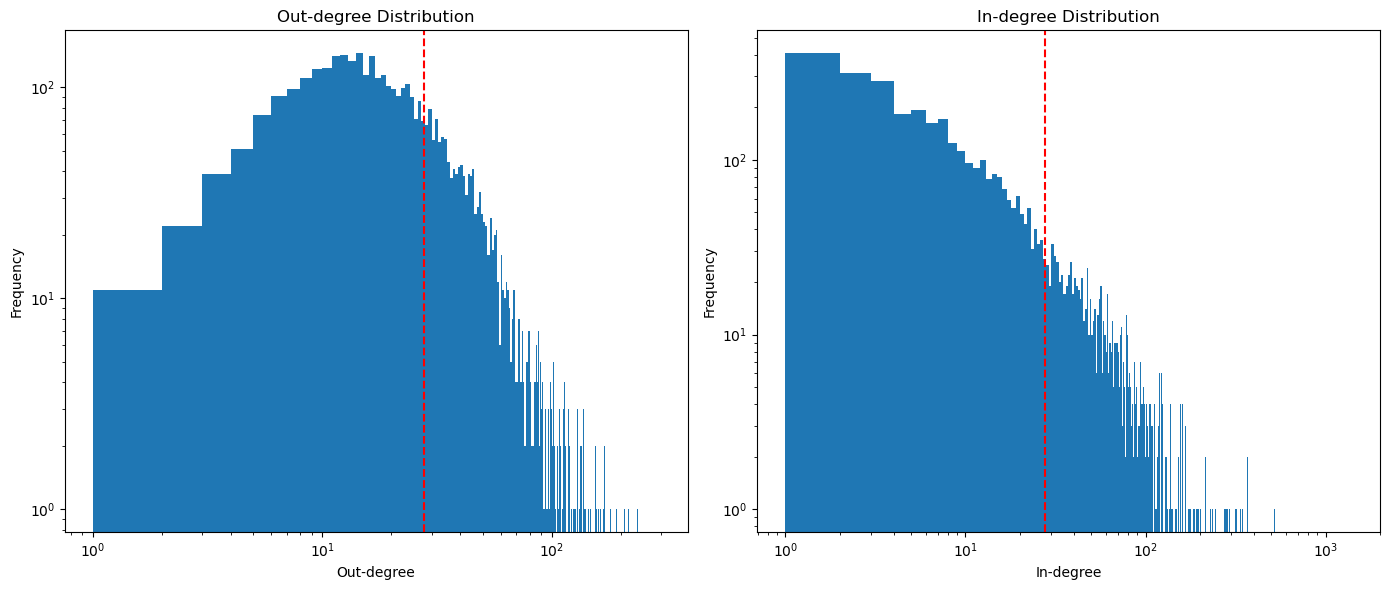

In [19]:
out_degree_sequence = [d for n, d in C.out_degree()]
in_degree_sequence = [d for n, d in C.in_degree()]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Out-degree
axs[0].hist(out_degree_sequence, bins=range(min(out_degree_sequence), max(out_degree_sequence)+1))
axs[0].axvline(np.mean(out_degree_sequence), color='r', linestyle='dashed')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("Out-degree")
axs[0].set_ylabel("Frequency")
axs[0].set_title("Out-degree Distribution")

# In-degree
axs[1].hist(in_degree_sequence, bins=range(min(in_degree_sequence), max(in_degree_sequence)+1))
axs[1].axvline(np.mean(in_degree_sequence), color='r', linestyle='dashed')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel("In-degree")
axs[1].set_ylabel("Frequency")
axs[1].set_title("In-degree Distribution")

plt.tight_layout()
plt.show()

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


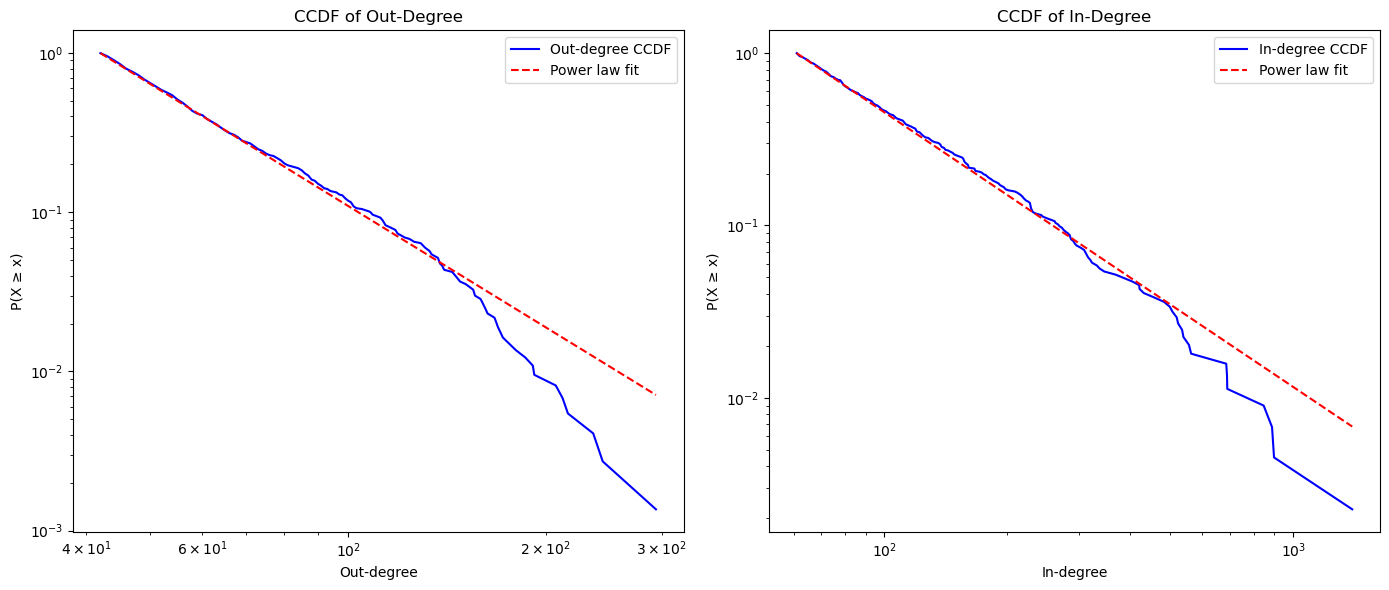

Out-degree fit:
  Alpha: 3.5278964558749717
  xmin: 42.0

In-degree fit:
  Alpha: 2.590278465907415
  xmin: 61.0


In [20]:
import powerlaw
import matplotlib.pyplot as plt

out_degree_sequence = [d for n, d in C.out_degree()]
in_degree_sequence = [d for n, d in C.in_degree()]

fig, axs = plt.subplots(1, 2, figsize=(14,6))

# Fit e plot out-degree
fit_out = powerlaw.Fit(out_degree_sequence, discrete=True)
ax0 = fit_out.plot_ccdf(label='Out-degree CCDF', color='b', ax=axs[0])
fit_out.power_law.plot_ccdf(color='r', linestyle='--', label='Power law fit', ax=ax0)
axs[0].set_xlabel("Out-degree")
axs[0].set_ylabel("P(X ≥ x)")
axs[0].legend()
axs[0].set_title("CCDF of Out-Degree")

# Fit e plot in-degree
fit_in = powerlaw.Fit(in_degree_sequence, discrete=True)
ax1 = fit_in.plot_ccdf(label='In-degree CCDF', color='b', ax=axs[1])
fit_in.power_law.plot_ccdf(color='r', linestyle='--', label='Power law fit', ax=ax1)
axs[1].set_xlabel("In-degree")
axs[1].set_ylabel("P(X ≥ x)")
axs[1].legend()
axs[1].set_title("CCDF of In-Degree")

plt.tight_layout()
plt.show()

print("Out-degree fit:")
print("  Alpha:", fit_out.power_law.alpha)
print("  xmin:", fit_out.power_law.xmin)

print("\nIn-degree fit:")
print("  Alpha:", fit_in.power_law.alpha)
print("  xmin:", fit_in.power_law.xmin)


In [21]:
def test_power_law_fit(fit):
    # Calculate KS distance between data and fitted power law
    ks_distance = fit.power_law.KS(fit.data)
    print(f"KS distance: {ks_distance:.4f}")

    # Run bootstrap test to calculate p-value
    # This generates synthetic datasets from the fitted power law model
    # and compares their KS distances to the KS distance of our real data
    R, p_value = fit.distribution_compare('power_law', 'power_law', nested=True)
    print(f"Goodness of fit p-value: {p_value:.4f}")

    # Interpret the results
    if p_value > 0.1:
        print("Result: The power law is a plausible fit for our data (p > 0.1)")
        print("This means we cannot reject the hypothesis that our data follows a power law.")
    else:
        print("Result: The power law is not a plausible fit for our data (p ≤ 0.1)")
        print("We should consider alternative distributions that might better describe our data.")

# Run the tests for out-degree and in-degree
print("\nGoodness-of-fit test for Out-degree:")
test_power_law_fit(fit_out)
print("\nGoodness-of-fit test for In-degree:")
test_power_law_fit(fit_in)



Goodness-of-fit test for Out-degree:
KS distance: 0.0183
Goodness of fit p-value: 1.0000
Result: The power law is a plausible fit for our data (p > 0.1)
This means we cannot reject the hypothesis that our data follows a power law.

Goodness-of-fit test for In-degree:
KS distance: 0.0226
Goodness of fit p-value: 1.0000
Result: The power law is a plausible fit for our data (p > 0.1)
This means we cannot reject the hypothesis that our data follows a power law.


Assuming nested distributions
Assuming nested distributions


In [26]:
import pandas as pd

distributions = ['exponential', 'lognormal', 'truncated_power_law', 'stretched_exponential']

def compare_distributions(fit):
    results = pd.DataFrame(columns=['Distribution', 'R', 'p', 'Winner'])
    for i, dist_name in enumerate(distributions):
        R, p = fit.distribution_compare('power_law', dist_name)
        if R > 0 and p < 0.05:
            winner = "Power Law"
        elif R < 0 and p < 0.05:
            winner = dist_name.title()
        else:
            winner = "Inconclusive"
        results.loc[i] = [dist_name, R, p, winner]
    return results

print("Out-degree comparison:")
results_out = compare_distributions(fit_out)
print(results_out)

print("\nIn-degree comparison:")
results_in = compare_distributions(fit_in)
print(results_in)


Out-degree comparison:
            Distribution          R         p               Winner
0            exponential  23.078984  0.008605            Power Law
1              lognormal  -2.673841  0.116240         Inconclusive
2    truncated_power_law  -3.763281  0.006080  Truncated_Power_Law
3  stretched_exponential  -2.944259  0.112305         Inconclusive

In-degree comparison:
            Distribution          R         p               Winner
0            exponential  53.746527  0.000399            Power Law
1              lognormal  -1.731463  0.232951         Inconclusive
2    truncated_power_law  -2.612771  0.022258  Truncated_Power_Law
3  stretched_exponential  -1.873708  0.276116         Inconclusive


Assuming nested distributions
Assuming nested distributions


Calculating best minimal value for power law fit
/home/stefano/anaconda3/envs/AVRCenv/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/home/stefano/anaconda3/envs/AVRCenv/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /
Calculating best minimal value for power law fit


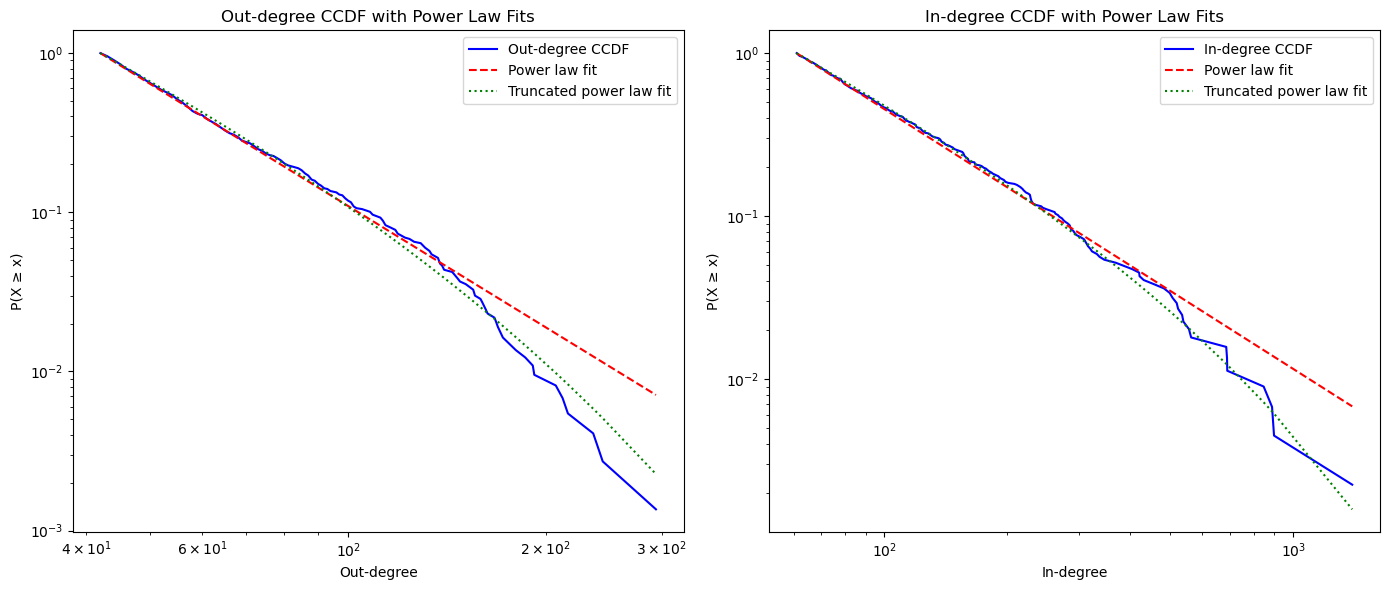

In [23]:

out_degree_sequence = [d for n, d in C.out_degree()]
in_degree_sequence = [d for n, d in C.in_degree()]

fig, axs = plt.subplots(1, 2, figsize=(14,6))

# Out-degree
fit_out = powerlaw.Fit(out_degree_sequence, discrete=True)
ax0 = fit_out.plot_ccdf(label='Out-degree CCDF', color='b', ax=axs[0])
fit_out.power_law.plot_ccdf(color='r', linestyle='--', label='Power law fit', ax=ax0)
fit_out.truncated_power_law.plot_ccdf(color='g', linestyle=':', label='Truncated power law fit', ax=ax0)
ax0.set_xlabel("Out-degree")
ax0.set_ylabel("P(X ≥ x)")
ax0.legend()
ax0.set_title("Out-degree CCDF with Power Law Fits")

# In-degree
fit_in = powerlaw.Fit(in_degree_sequence, discrete=True)
ax1 = fit_in.plot_ccdf(label='In-degree CCDF', color='b', ax=axs[1])
fit_in.power_law.plot_ccdf(color='r', linestyle='--', label='Power law fit', ax=ax1)
fit_in.truncated_power_law.plot_ccdf(color='g', linestyle=':', label='Truncated power law fit', ax=ax1)
ax1.set_xlabel("In-degree")
ax1.set_ylabel("P(X ≥ x)")
ax1.legend()
ax1.set_title("In-degree CCDF with Power Law Fits")

plt.tight_layout()
plt.show()


#### Results

The out‑degree distribution partially follows a power law, but the truncated power law provides a better fit. This is likely due to the nature of the early version of Wikipedia: most pages were relatively short and thus contained few hyperlinks. Only a small number of pages were well‑developed and included a large number of links (e.g. “United States”), leading to a faster decay in the tail of the out‑degree distribution.

Similarly, the in‑degree distribution also follows a truncated power law. Most articles were linked by only a handful of other pages, while a small number of key articles (again, like “United States”) gathered many incoming links.

Probably, in the current version of Wikipedia, there are many more long articles rich in intenionally structurated hyperlinks, as well as a vast number of smaller articles that cover a wide range of specialized topics. This growth has likely smoothed the degree distribution that better approximates a pure power law.

Overall, both out‑degree and in‑degree distributions are not fully scale‑free, but still are highly skewed: **a few hub articles have very high degree values, and most pages have low degree values.**

We will focus on hubs and centrality in the next notebook.

### Assortativity 

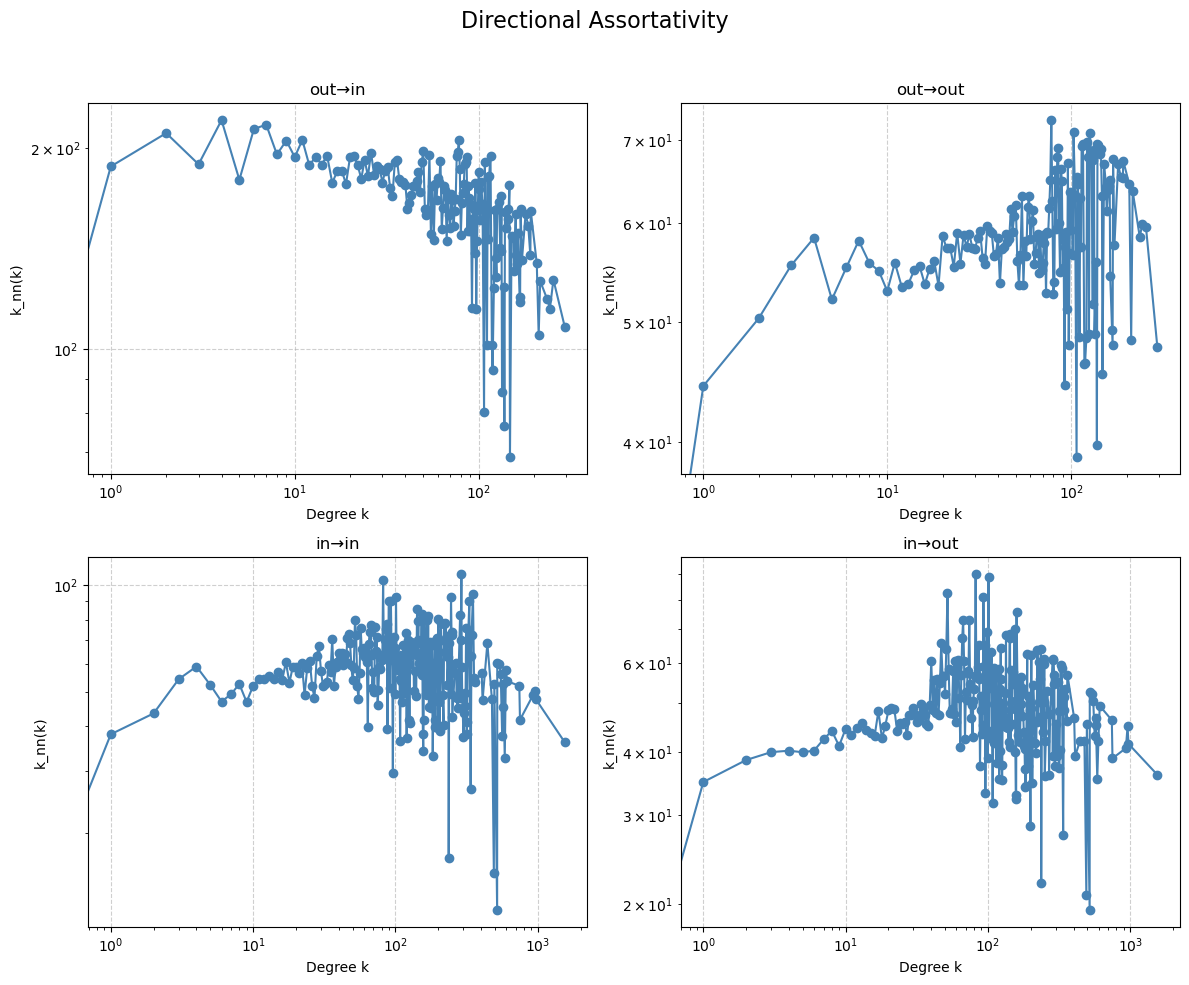

Out-In: -0.05620919781872192
Out-Out: 0.02699131727196437
In-In: -0.030068185306225678
In-Out: 0.0012343579568508956


In [24]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

combinations = {
    "out→in": ('out', 'in'),
    "out→out": ('out', 'out'),
    "in→in": ('in', 'in'),
    "in→out": ('in', 'out'),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (label, (source, target)) in enumerate(combinations.items()):
    knn = nx.average_degree_connectivity(G, source=source, target=target)
    k_vals = np.array(sorted(knn.keys()))
    knn_vals = np.array([knn[k] for k in k_vals])

    axes[i].plot(k_vals, knn_vals, 'o-', color='steelblue')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(label)
    axes[i].set_xlabel("Degree k")
    axes[i].set_ylabel("k_nn(k)")
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Directional Assortativity", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#Calculate assortativity coefficients for in and out degrees
print("Out-In:", nx.degree_assortativity_coefficient(G, x='out', y='in'))
print("Out-Out:", nx.degree_assortativity_coefficient(G, x='out', y='out'))
print("In-In:", nx.degree_assortativity_coefficient(G, x='in', y='in'))
print("In-Out:", nx.degree_assortativity_coefficient(G, x='in', y='out'))


### Results

To check assortativity in a directed network, we use each combination of in-degree and out-degree. The results show highly noisy patterns, probably due to the small number of examples with high degree.
Considering that all assortativity coefficients are near zero, we can conclude that the network is mainly neutral, with no significant preference for hubs to connect with other hubs nodes or low-degree nodes.

## Summary and Conclusions

This analysis of the Wikipedia network reveals several structural properties:

1. **Network Structure**: The network contains 4,604 nodes with 119,882 directed edges. While not fully connected, it has a giant weakly connected component containing 4,589 nodes and a large strongly connected component with 4,051 nodes.

2. **Small-World Properties**: The network exhibits small-world characteristics with a diameter of 9 and average path length of 3.18, indicating efficient connectivity.

3. **Degree Distribution**: The out-degree and in-degree distributions follow a truncated power law rather than a pure power law, likely reflecting the early developmental stage of Wikipedia (2007).

4. **Assortativity**: The network shows neutral degree assortativity across all in-degree/out-degree combinations, with coefficients near zero.
